In [1]:
import numpy as np
from Functions_Binned_Analysis import Discovery_Limit, IAXO, L_ES
import os
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin'

q0 = 9.0 # 3-sigma discovery limit
m2 = 1e-3 # [eV]
g_arb = 1.0e-11 # [GeV^-1]
L_source = L_ES
w_min = 100e-3 # [keV]
w_max = 20.0 # [keV]
res_on = True
N_bins = 199
w_res = 100e-3 # [keV]

delta_m21_sq_vals = np.logspace(-18.0,-10.0,1000) # [eV^2]
x = np.sqrt(delta_m21_sq_vals)
g_disc_IAXO_pi4 = np.empty_like(delta_m21_sq_vals,dtype=float)
g_disc_IAXO_pi8 = np.empty_like(delta_m21_sq_vals,dtype=float)
g_disc_IAXO_pi16 = np.empty_like(delta_m21_sq_vals,dtype=float)
g_disc_IAXO_pi32 = np.empty_like(delta_m21_sq_vals,dtype=float)


for k,dm2 in enumerate(delta_m21_sq_vals):
    mixing = np.pi/4.0
    g_disc_IAXO_pi4[k] = Discovery_Limit(q0,g_arb,m2,dm2,mixing,IAXO["B"],IAXO["L"],L_source,IAXO["S"],IAXO["t"],IAXO["eps_T"],IAXO["eps_D"],
                                         w_min,w_max,N_bins,
                                         res_on=res_on,w_res=w_res,
                                         m2_bounds=(m2,m2))
    mixing = np.pi/8.0
    g_disc_IAXO_pi8[k] = Discovery_Limit(q0,g_arb,m2,dm2,mixing,IAXO["B"],IAXO["L"],L_source,IAXO["S"],IAXO["t"],IAXO["eps_T"],IAXO["eps_D"],
                                         w_min,w_max,N_bins,
                                         res_on=res_on,w_res=w_res,
                                         m2_bounds=(m2,m2))
    mixing = np.pi/16.0
    g_disc_IAXO_pi16[k] = Discovery_Limit(q0,g_arb,m2,dm2,mixing,IAXO["B"],IAXO["L"],L_source,IAXO["S"],IAXO["t"],IAXO["eps_T"],IAXO["eps_D"],
                                          w_min,w_max,N_bins,
                                          res_on=res_on,w_res=w_res,
                                          m2_bounds=(m2,m2))
    mixing = np.pi/32.0
    g_disc_IAXO_pi32[k] = Discovery_Limit(q0,g_arb,m2,dm2,mixing,IAXO["B"],IAXO["L"],L_source,IAXO["S"],IAXO["t"],IAXO["eps_T"],IAXO["eps_D"],
                                          w_min,w_max,N_bins,
                                          res_on=res_on,w_res=w_res,
                                          m2_bounds=(m2,m2))


np.savetxt("results_data/Quasi-degenerate/Quasideg_IAXO_disc_pi4.dat",
           np.column_stack((x,g_disc_IAXO_pi4)),
           fmt="%.6e",
           header="sqrt(Delta_m21^2) [eV]    g_IAXO [GeV^-1]    (varphi = pi/4, w_res = 100 eV)")

np.savetxt("results_data/Quasi-degenerate/Quasideg_IAXO_disc_pi8.dat",
           np.column_stack((x,g_disc_IAXO_pi8)),
           fmt="%.6e",
           header="sqrt(Delta_m21^2) [eV]    g_IAXO [GeV^-1]    (varphi = pi/8, w_res = 100 eV)")

np.savetxt("results_data/Quasi-degenerate/Quasideg_IAXO_disc_pi16.dat",
           np.column_stack((x,g_disc_IAXO_pi16)),
           fmt="%.6e",
           header="sqrt(Delta_m21^2) [eV]    g_IAXO [GeV^-1]    (varphi = pi/16, w_res = 100 eV)")

np.savetxt("results_data/Quasi-degenerate/Quasideg_IAXO_disc_pi32.dat",
           np.column_stack((x,g_disc_IAXO_pi32)),
           fmt="%.6e",
           header="sqrt(Delta_m21^2) [eV]    g_IAXO [GeV^-1]    (varphi = pi/32, w_res = 100 eV)")

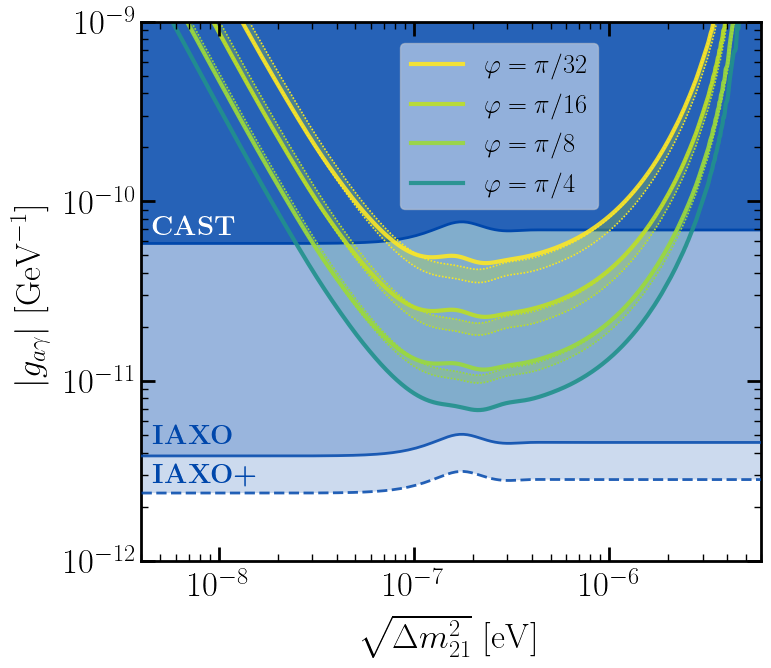

In [3]:
#%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from palettable.colorbrewer.sequential import YlOrRd_5
from palettable.cartocolors.qualitative import Bold_10
import os
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin'

plt.rcParams.update({
   "text.usetex":True,
   "font.size":25,
   "axes.formatter.limits":[-3,3],
   "axes.linewidth":2,
   "lines.linewidth":2,
   "xtick.top":True,
   "xtick.bottom":True,
   "ytick.left":True,
   "ytick.right":True,
   "xtick.minor.visible":True,
   "ytick.minor.visible":True,
   "xtick.direction":"in",
   "ytick.direction":"in",
   "xtick.major.width":2,
   "xtick.minor.width":1,
   "ytick.major.width":2,
   "ytick.minor.width":1,
   "xtick.major.size":10,
   "xtick.minor.size":5,
   "ytick.major.size":10,
   "ytick.minor.size":5,
   "figure.figsize":[8,7],
   "savefig.dpi":300,
   "savefig.transparent":True
})

gs = gridspec.GridSpec(1,1,wspace=0.0)
fig = plt.figure()
ax = fig.add_subplot(gs[0])
ax.set_xlim(left=4e-9,right=6e-6)
ax.set_ylim(bottom=1e-12,top=1e-9)
ax.tick_params(axis='x',which='major',pad=8)
ax.tick_params(axis='x',which='minor',pad=8)
ax.set_xlabel(r"$\sqrt{\Delta m_{21}^2}\ [\mathrm{eV}]$",labelpad=10)
ax.set_ylabel(r"$|g_{a\gamma}|\ [\mathrm{GeV}^{-1}]$",labelpad=10)

folder1 = "input_data"
folder2 = "results_data"
greens = [plt.cm.viridis(v) for v in [0.5,0.8+0.049, 0.85+0.049, 0.950+0.049]]

# Exclusion limit CAST @95% CL
CAST = np.loadtxt(os.path.join(folder1,"CAST_exclusion.dat"))
x_CAST = CAST[:,0]
g_excl_CAST = CAST[:,1]
plt.loglog(x_CAST,g_excl_CAST,color="#0047AB",zorder=1)
ax.fill_between(x_CAST,g_excl_CAST,ax.get_ylim()[1],facecolor="#0047AB",zorder=0.5,alpha=0.85)
ax.text(4.56e-9,6.5e-11,r'{\bf CAST}',fontsize=20,color='w',zorder=1000)

# Exclusion limit IAXO @95% CL
IAXO = np.loadtxt(os.path.join(folder1,"IAXO_projection.dat"))
x_IAXO = IAXO[:,0]
g_excl_IAXO = IAXO[:,1]
plt.loglog(x_IAXO,g_excl_IAXO,color="#0047AB",zorder=8,alpha=0.85)
ax.fill_between(x_IAXO,g_excl_IAXO,g_excl_CAST,facecolor="#0047AB",zorder=0.05,alpha=0.4)
ax.text(4.56e-9,4.5e-12,r'{\bf IAXO}',fontsize=20,color="#0047AB",zorder=1000)

# Exclusion limit IAXOplus @95% CL
IAXOplus = np.loadtxt(os.path.join(folder1,"IAXOplus_projection.dat"))
x_IAXOplus = IAXOplus[:,0]
g_excl_IAXOplus = IAXOplus[:,1]
plt.loglog(x_IAXOplus,g_excl_IAXOplus,color="#0047AB",ls='--',zorder=8,alpha=0.85)
ax.fill_between(x_IAXOplus,g_excl_IAXOplus,g_excl_IAXO,facecolor="#0047AB",zorder=0.05,alpha=0.2)
ax.text(4.56e-9,2.7e-12,r'{\bf IAXO+}',fontsize=20,color="#0047AB",zorder=1000)

# Discovery limit IAXO (varphi = pi/4)
IAXO_pi4 = np.loadtxt(os.path.join(folder2,"Quasi-degenerate","Quasideg_IAXO_disc_pi4.dat"))
x_IAXO_pi4 = IAXO_pi4[:,0]
g_disc_IAXO_pi4 = IAXO_pi4[:,1]
plt.loglog(x_IAXO_pi4,g_disc_IAXO_pi4,color=greens[0],lw=3,label=r'$\varphi = \pi/4$',zorder=2,alpha=0.9)

# Discovery limit IAXO (varphi = pi/8)
IAXO_pi8 = np.loadtxt(os.path.join(folder2,"Quasi-degenerate","Quasideg_IAXO_disc_pi8.dat"))
x_IAXO_pi8 = IAXO_pi8[:,0]
g_disc_IAXO_pi8 = IAXO_pi8[:,1]
plt.loglog(x_IAXO_pi8,g_disc_IAXO_pi8,color=greens[1],lw=3,label=r'$\varphi = \pi/8$',zorder=2,alpha=0.9)

# Discovery limit IAXO (varphi = pi/16)
IAXO_pi16 = np.loadtxt(os.path.join(folder2,"Quasi-degenerate","Quasideg_IAXO_disc_pi16.dat"))
x_IAXO_pi16 = IAXO_pi16[:,0]
g_disc_IAXO_pi16 = IAXO_pi16[:,1]
plt.loglog(x_IAXO_pi16,g_disc_IAXO_pi16,color=greens[2],lw=3,label=r'$\varphi = \pi/16$',zorder=2,alpha=0.9)

# Discovery limit IAXO (varphi = pi/32)
IAXO_pi32 = np.loadtxt(os.path.join(folder2,"Quasi-degenerate","Quasideg_IAXO_disc_pi32.dat"))
x_IAXO_pi32 = IAXO_pi32[:,0]
g_disc_IAXO_pi32 = IAXO_pi32[:,1]
plt.loglog(x_IAXO_pi32,g_disc_IAXO_pi32,color=greens[3],lw=3,label=r'$\varphi = \pi/32$',zorder=2,alpha=0.9)

# Distinction region
logg_CAST_on_IAXO_pi4 = np.interp(np.log10(x_IAXO_pi4),np.log10(x_CAST),np.log10(g_excl_CAST))
g_CAST_on_IAXO_pi4 = 10**logg_CAST_on_IAXO_pi4
mask = g_CAST_on_IAXO_pi4 > g_disc_IAXO_pi4
ax.fill_between(
    x_IAXO_pi4,
    g_disc_IAXO_pi4,
    g_CAST_on_IAXO_pi4,
    where=mask,
    facecolor=greens[0],
    interpolate=True,
    alpha=0.2,
    zorder=0.1           
)

# Analytic scaling
def Bestf_high(phi):
    u = np.sin(2*phi)**2
    return np.sin(2*phi)/(2-u)**0.25
def Bestf_low(phi):
    return np.sin(2*phi)

g_ref = g_disc_IAXO_pi4

g_high = g_ref/Bestf_high(np.pi/8.0)
g_low = g_ref/Bestf_low(np.pi/8.0)
ax.loglog(x_IAXO_pi8,g_high,color=greens[1],lw=1.2,ls=(0,(1,1)),zorder=1.1)
ax.loglog(x_IAXO_pi8,g_low,color=greens[1],lw=1.2,ls=(0,(1,1)),zorder=1.1)
ax.fill_between(x_IAXO_pi8,g_low,g_high,facecolor=greens[1],alpha=0.25,zorder=1.1)

g_high = g_ref/Bestf_high(np.pi/16.0)
g_low = g_ref/Bestf_low(np.pi/16.0)
ax.loglog(x_IAXO_pi16,g_high,color=greens[2],lw=1.2,ls=(0,(1,1)),zorder=1.1)
ax.loglog(x_IAXO_pi16,g_low,color=greens[2],lw=1.2,ls=(0,(1,1)),zorder=1.1)
ax.fill_between(x_IAXO_pi16,g_low,g_high,facecolor=greens[2],alpha=0.25,zorder=1.1)

g_high = g_ref/Bestf_high(np.pi/32.0)
g_low = g_ref/Bestf_low(np.pi/32.0)
ax.loglog(x_IAXO_pi32,g_high,color=greens[3],lw=1.2,ls=(0,(1,1)),zorder=1.1)
ax.loglog(x_IAXO_pi32,g_low,color=greens[3],lw=1.2,ls=(0,(1,1)),zorder=1.1)
ax.fill_between(x_IAXO_pi32,g_low,g_high,facecolor=greens[2],alpha=0.25,zorder=1.1)

ax.xaxis.set_zorder(1000)
ax.yaxis.set_zorder(1000)
handles,labels = ax.get_legend_handles_labels()
leg = ax.legend(handles[::-1],labels[::-1],fontsize=19,loc='upper right',framealpha=0.5,bbox_to_anchor=(0.7580,0.985))

fig.savefig("plots/Mixing-angle.pdf",bbox_inches="tight")
fig.savefig("plots/Mixing-angle.png",bbox_inches="tight")
plt.show()